# SALT3 - Run-Scoped CPT Training

This notebook trains, resumes, or continues one CPT run. All mutable state is isolated under `/content/drive/MyDrive/SALT3/runs/<RUN_NAME>/`.

In [1]:
from huggingface_hub import login
try:
    from google.colab import userdata
    login(token=userdata.get('HF_TOKEN'))
except Exception:
    import os
    if os.environ.get('HF_TOKEN'):
        login(token=os.environ['HF_TOKEN'])

In [ ]:
%%capture
!pip install -U "huggingface_hub>=1.13.0" transformers accelerate datasets safetensors sentencepiece tokenizers pandas scikit-learn matplotlib tqdm
# xformers wheels pin exact torch versions, so an unpinned '-U xformers' can silently
# replace Colab's CUDA torch under %%capture. --no-deps keeps torch untouched; if the
# wheel is ABI-incompatible, importing xformers simply fails and the patched model.py
# falls back to its pure-PyTorch SwiGLU (identical math and w12/w3 parameter names).
!pip install --no-deps -U xformers

In [ ]:
from pathlib import Path
import gc
import shutil
import sys

import torch
import transformers
from transformers import AutoModelForMaskedLM, AutoTokenizer, EarlyStoppingCallback

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', exc)

PROJECT_ROOT = Path('/content/drive/MyDrive/SALT3') if Path('/content/drive/MyDrive').exists() else Path.cwd() / 'SALT3'
CODE_DIR = PROJECT_ROOT / 'code'
CODE_DIR.mkdir(parents=True, exist_ok=True)
for import_path in ('/content', str(CODE_DIR), str(PROJECT_ROOT)):
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

import salt3_common as _salt3_common
print('salt3_common:', _salt3_common.__file__)

from salt3_common import (
    JsonlMetricsCallback, configure_environment, copy_neobert_remote_files,
    create_or_load_run, diagnose_model_health, embedding_fingerprint, ensure_dir,
    eval_with_perplexity, get_last_checkpoint, inspect_tokenized_dataset,
    load_model_safe, make_mlm_collator, make_mlm_datasets, make_neo_mlm_trainer_class,
    plot_training_curves, resolve_ref, set_seed, tokenizer_fingerprint,
    train_with_run_resume, training_args, validate_model_artifact, write_json,
)

configure_environment()
set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NeoMLMTrainer = make_neo_mlm_trainer_class()
print('Device:', DEVICE)
print('Project root:', PROJECT_ROOT)
# The install cell is %%capture'd, so report what actually got installed —
# a silently swapped torch/transformers is otherwise invisible until mid-run.
print('Versions: torch', torch.__version__, '| transformers', transformers.__version__)
try:
    import xformers
    print('xformers:', xformers.__version__)
except Exception as exc:
    print('xformers unavailable — pure-PyTorch SwiGLU fallback will be used:', exc)

## Configure this run

Set `MODE`, `RUN_NAME`, and `BASE_MODEL_REF`. For `resume`, `BASE_MODEL_REF` is loaded from the existing run config.

In [ ]:
MODE = 'resume'  # 'new', 'resume', or 'continue'
RUN_NAME = 'new-v3-3m'
BASE_MODEL_REF = 'init/videberta_salt_init_v3_proj/model'
ALLOW_OVERWRITE = False
# NOTE: with MODE='resume', the values below are read from the run's saved
# run_config.json — any edits here are reported as ignored, not applied.

DATA_CONFIG = {
    # num_examples: how many CulturaX docs to stream & tokenize (cached to Drive).
    # Cache is keyed by (num_examples, max_seq_len, eval_ratio, seed, tokenizer
    # fingerprint); documents are routed to train/eval BEFORE chunk packing so no
    # document leaks across the split. If the pruned tokenizer changes, SALT3
    # rebuilds the cache instead of silently reusing stale token IDs.
    # Tip: set this to your LARGEST planned experiment (e.g. 3_000_000),
    # then use num_chunks to take a smaller slice for quick experiments.
    'num_examples': 3_000_000,
    'max_seq_len': 1024,
    # num_chunks: how many chunks to actually USE from the tokenizer-specific cache.
    # None = use all chunks from the 3M-doc cache for the full run.
    # Set to e.g. 40_000 or 400_000 for smaller experiments without re-tokenizing.
    'num_chunks': None,
    'eval_ratio': 0.02,
    'mlm_probability': 0.20,
    'seed': 42,
}

TRAIN_CONFIG = {
    'run_name': RUN_NAME,
    'num_train_epochs': 1,
    'max_steps': -1,
    'per_device_train_batch_size': 32,
    'per_device_eval_batch_size': 32,
    'gradient_accumulation_steps': 16,
    'learning_rate': 1e-4,
    'adam_beta2': 0.95,
    'weight_decay': 0.01,
    'warmup_ratio': 0.05,
    'logging_steps': 25,
    'eval_steps': 200,
    'save_steps': 200,
    'save_total_limit': 5,
    'early_stopping_patience': 5,
}

RUN_CONFIG = {
    'strategy': 'simple_cpt',
    'seed': 42,
    'data': DATA_CONFIG,
    'training': TRAIN_CONFIG,
}

run = create_or_load_run(
    PROJECT_ROOT,
    mode=MODE,
    run_name=RUN_NAME,
    base_model_ref=BASE_MODEL_REF,
    config=RUN_CONFIG,
    allow_overwrite=ALLOW_OVERWRITE,
)
BASE_MODEL_PATH = resolve_ref(PROJECT_ROOT, run['base_model_ref'])
CHECKPOINT_DIR = Path(run['checkpoint_dir'])
FINAL_MODEL_DIR = Path(run['final_model_dir'])
METRICS_PATH = Path(run['metrics_path'])
PLOTS_DIR = Path(run['plots_dir'])
DATASET_CACHE = ensure_dir(PROJECT_ROOT / 'datasets')

print('Mode           :', MODE)
print('Run name       :', run['run_name'])
print('Run dir        :', run['run_dir'])
print('Base model ref :', run['base_model_ref'])
print('Base model path:', BASE_MODEL_PATH)
print('Checkpoint dir :', CHECKPOINT_DIR)
print('Final model dir:', FINAL_MODEL_DIR)

In [ ]:
import json

validate_model_artifact(BASE_MODEL_PATH)
salt_cfg_path = BASE_MODEL_PATH.parent / 'salt_config.json'
if salt_cfg_path.exists():
    salt_cfg = json.loads(salt_cfg_path.read_text(encoding='utf-8'))
    print('Decoder init  :', salt_cfg.get('decoder_init', 'unknown'))
    print('Special rows  :', salt_cfg.get('special_token_init', 'unknown'))
    decoder_init = salt_cfg.get('decoder_init', '')
    if decoder_init not in ('projected_from_neobert_decoder', 'tied_to_embeddings', 'global_emb_to_decoder_map'):
        print('WARNING: init artifact has unrecognized decoder_init; pre-train MLM loss may be dominated by a random LM head.')
    if salt_cfg.get('special_token_init') != 'copied_from_neobert_specials':
        print('WARNING: init artifact does not record copied NeoBERT special-token rows; MLM eval can fail even when normal token embeddings look healthy.')
else:
    print('WARNING: salt_config.json not found next to base model; cannot verify decoder init.')

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, trust_remote_code=True)
model = load_model_safe(BASE_MODEL_PATH, model_cls=AutoModelForMaskedLM, device=DEVICE)
fingerprint = embedding_fingerprint(model)
tok_fp = tokenizer_fingerprint(tokenizer)
write_json(Path(run['run_dir']) / 'base_embedding_fingerprint.json', fingerprint)
write_json(Path(run['run_dir']) / 'tokenizer_fingerprint.json', tok_fp)
print('Tokenizer vocab:', len(tokenizer))
print('Model vocab    :', model.config.vocab_size)
print('Tokenizer fp   :', tok_fp)
print('Embedding fp   :', fingerprint)

# Diagnose whether model weights loaded correctly — and HALT on failure: a printed
# warning scrolls past under 'Run all' and a broken load wastes the whole session.
health = diagnose_model_health(model, tokenizer, device=DEVICE)
if not str(health.get('diagnosis', '')).startswith('OK'):
    raise RuntimeError(
        f"Model health check failed: {health.get('diagnosis')!r}. "
        'Fix the init artifact / weight loading before training.'
    )

In [8]:
data_cfg = run['data']
train_dataset, eval_dataset = make_mlm_datasets(
    tokenizer=tokenizer,
    cache_dir=DATASET_CACHE,
    num_examples=data_cfg['num_examples'],
    max_seq_len=data_cfg['max_seq_len'],
    num_chunks=data_cfg.get('num_chunks'),  # None = use all cached chunks
    eval_ratio=data_cfg['eval_ratio'],
    seed=data_cfg['seed'],
)
inspect_tokenized_dataset(train_dataset, tokenizer, name='train')
inspect_tokenized_dataset(eval_dataset, tokenizer, name='eval')
data_collator = make_mlm_collator(tokenizer, mlm_probability=data_cfg['mlm_probability'])
pre_rows = [train_dataset[i] for i in range(min(4, len(train_dataset)))]
original_ids = torch.tensor([row['input_ids'] for row in pre_rows], dtype=torch.long)
sample = data_collator(pre_rows)
masked_positions = sample['labels'] != -100
mask_token_id = tokenizer.mask_token_id
masked_total = int(masked_positions.sum())
mask_replaced = int((sample['input_ids'][masked_positions] == mask_token_id).sum())
kept_same = int((sample['input_ids'][masked_positions] == original_ids[masked_positions]).sum())
random_replaced = masked_total - mask_replaced - kept_same
print('Train chunks:', len(train_dataset), 'Eval chunks:', len(eval_dataset))
print('Sample batch:', tuple(sample['input_ids'].shape), 'masked:', masked_total)
print(
    'Mask replacement:',
    f'[MASK]={mask_replaced}/{masked_total} ({mask_replaced/max(masked_total, 1):.1%}) |',
    f'same={kept_same}/{masked_total} ({kept_same/max(masked_total, 1):.1%}) |',
    f'random={random_replaced}/{masked_total} ({random_replaced/max(masked_total, 1):.1%})',
)

Tokenizer fingerprint: 3487ef147c62 (DebertaV2Tokenizer, vocab=30522)
Dataset cache key    : culturax_vi_3000000_seq1024_tok3487ef147c62
Loading cached dataset from /content/drive/MyDrive/SALT3/datasets/culturax_vi_3000000_seq1024_tok3487ef147c62 ...


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

  Using 2,805,277 train + 57,251 eval chunks
── Tokenized train sanity ──
  Rows: 2,805,277
  Example 0: len=1024 min_id=5 max_id=30113 oob=0 unk=0
    decode: ấy và là trận thắng loại trực tiếp thứ 20 của cô ấy nói chung. Từ sau khi Valery Karpin nên lắm quyền các cầu thủ Nga đã thi đấu cực kì ấn tượng khi sau 6 trận ở vòng loại World Cup những chú gấu Nga đã đem về 13 điểm với 4 trận thắng, 1 trận hòa và chỉ để thua duy nhất một trận. Khuyến mãi đa dạng, tiền thưởng lớn Mourinho và các cầu thủ Tottenham đang trở thành đề tài châm biếm của xã hội Anh khi nhóm người này ngang nhiên tổ chức buổi tập không chính thức, qua đó tự phá quy định tự cách ly. D
  Example 1: len=1024 min_id=3 max_id=30158 oob=0 unk=1
    decode: , chống tham nhũng; ban hành mới 17 văn bản, sửa đổi bổ sung 14 văn bản và bãi bỏ 5 văn bản quy định chế độ định mức, tiêu chuẩn trong đơn vị. Ban Nội chính Tỉnh ủy đã ban hành Công văn số 218-CV/BNCTU ngày 17-2-2017 hướng dẫn một số nội dung về báo cáo định kỳ công tác 

In [ ]:
train_cfg = dict(run['training'])
early_stopping_patience = train_cfg.pop('early_stopping_patience', 5)
args = training_args(CHECKPOINT_DIR, **train_cfg)
metrics = JsonlMetricsCallback(METRICS_PATH)
effective_batch_size = args.per_device_train_batch_size * args.gradient_accumulation_steps
estimated_optimizer_steps = max(1, (len(train_dataset) + effective_batch_size - 1) // effective_batch_size)
estimated_training_evals = estimated_optimizer_steps // args.eval_steps
trainer = NeoMLMTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience), metrics.callback],
)
print('Trainer GA normalization on (model_accepts_loss_kwargs=False):', not trainer.model_accepts_loss_kwargs)
checkpoint = get_last_checkpoint(CHECKPOINT_DIR)
print('Early stopping patience:', early_stopping_patience)
print('Estimated optimizer steps:', estimated_optimizer_steps)
print('Estimated training evals :', estimated_training_evals)
if estimated_training_evals <= early_stopping_patience:
    print('Warning: early stopping is unlikely to trigger with the current eval cadence.')
print('Existing checkpoint:', checkpoint)

import math
if masked_total == 0:
    # zero masked tokens is the most broken collator state, not a pass
    raise RuntimeError(
        'MLM collator masked 0 tokens in the probe batch — the objective is broken '
        '(check mlm_probability and the special-token mask).'
    )
if mask_replaced != masked_total:
    print(
        'WARNING: MLM collator is not doing full [MASK] replacement.',
        'This makes the pre-train eval non-comparable to NeoBERT pretraining and can inflate loss dramatically.',
    )
pre = eval_with_perplexity(trainer)
expected_random = math.log(model.config.vocab_size)
print(f'Pre-train eval      : {pre}')
print(f'Expected random loss: {expected_random:.2f} (= log({model.config.vocab_size}))')
if math.isnan(pre['eval_loss']):
    raise RuntimeError(
        'Pre-train eval_loss is NaN — eval batches likely contain no masked labels, '
        'or the forward pass produced NaNs.'
    )
if pre['eval_loss'] > expected_random * 1.2:
    print(f'⚠ eval_loss ({pre["eval_loss"]:.2f}) >> random ({expected_random:.2f}) — model is confidently wrong on this eval set.')
    print('  First suspect: MLM objective mismatch. Confirm the batch above shows 100% [MASK], 0% same, 0% random.')
    print('  Second suspect: stale tokenized dataset cache or tokenizer/id mismatch. Check the dataset cache key and decoded samples above.')
    print('  If both look correct, the remaining issue is init quality itself (projection/anchor coverage), not checkpoint loading.')
    if checkpoint is None:
        # only halt FRESH runs: a resumed run continues from trained checkpoint
        # weights, so the base model scoring badly here does not affect it
        raise RuntimeError(
            'Refusing to start a fresh CPT run from an init that scores worse than random — '
            'training would burn the session on a broken model.'
        )
    print('  Continuing: an existing checkpoint will be resumed, so the base-model score above is not what trains.')
elif pre['eval_loss'] < expected_random * 0.8:
    print(f'✓ eval_loss ({pre["eval_loss"]:.2f}) < random ({expected_random:.2f}) — init/tokenizer/dataset are aligned.')
else:
    print('Eval is near random. That can happen for a fresh init, but it should improve quickly during CPT if the objective and dataset are aligned.')

In [10]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM after cleanup: {free / 1e9:.1f}GB free / {total / 1e9:.1f}GB total')

VRAM after cleanup: 83.5GB free / 85.1GB total


In [11]:
result = train_with_run_resume(trainer, MODE)
post = eval_with_perplexity(trainer)
print('Global steps:', result.global_step)
print('Post-train eval:', post)
if 'eval_loss' in pre and 'eval_loss' in post:
    improved = post['eval_loss'] < pre['eval_loss']
    print(f'Loss improved: {"✓ YES" if improved else "✗ NO"} '
          f'({pre["eval_loss"]:.4f} → {post["eval_loss"]:.4f})')

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Resuming trainer checkpoint: /content/drive/MyDrive/SALT3/runs/new-v3-3m/checkpoints/checkpoint-5000


Step,Training Loss,Validation Loss
5200,21.498354,1.342133
5400,21.465789,1.342221
5480,21.398186,1.342097


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step
21.398186,1.341689,5480


Global steps: 5480
Post-train eval: {'eval_loss': 1.3416889905929565, 'eval_perplexity': 3.825499284261209}
Loss improved: ✓ YES (15.2117 → 1.3417)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model.py:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

rotary.py:   0%|          | 0.00/2.58k [00:00<?, ?B/s]

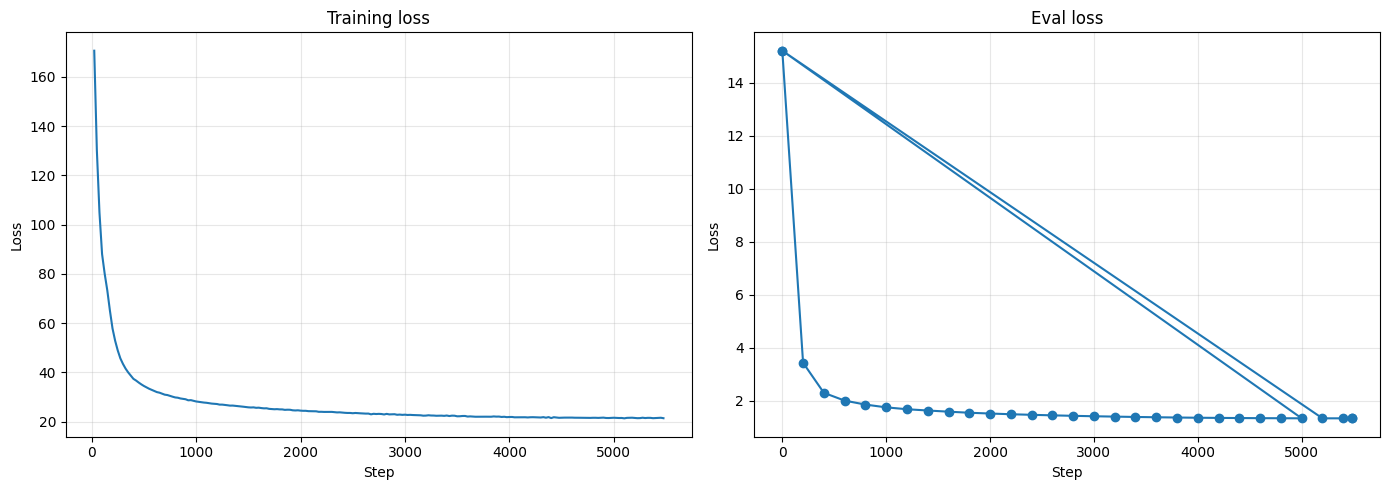

Saved final model: /content/drive/MyDrive/SALT3/runs/new-v3-3m/final_model
Final embedding fp: {'shape': [30522, 768], 'mean_norm': 1.2183864116668701, 'std_norm': 0.038483235985040665, 'sha256_first_rows': 'ff7a606cbab6397fd32309ea35a2c1494a5c6f89a022fdf03e447b7005f38e26'}


In [12]:
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
copy_neobert_remote_files(FINAL_MODEL_DIR)
final_fp = embedding_fingerprint(trainer.model)
write_json(Path(run['run_dir']) / 'final_embedding_fingerprint.json', final_fp)
plot_training_curves(METRICS_PATH, save_path=PLOTS_DIR / 'loss_curves.png')
print('Saved final model:', FINAL_MODEL_DIR)
print('Final embedding fp:', final_fp)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()